# The isochrone prior and the E(B-V) degeneracy

A radius-free synthetic photometry grid such as TSLTE tells you an
atmosphere's *colours*, not its size. At fixed effective temperature and
composition a log g = 1.5 giant and a log g = 4.5 dwarf differ by only
~0.025 mag — well inside typical photometric errors. The isochrone layer
(`MISTTrack`) refuses to let (Teff, log g) leave the locus a real star of a
given mass, age and composition occupies: it samples an evolutionary track
and lets MIST supply the atmosphere and the radius.

This notebook asks a sharp question on the real grids: **for a metal-poor
halo red giant, how much does the isochrone actually buy you?** The answer
has two halves that it is important not to conflate.

1. **The discrete dwarf/giant ambiguity — broken.** A free-atmosphere fit,
   with metallicity, reddening and distance all floating, leaves log g wide
   open: its posterior spans from the giant branch up toward dwarf gravities
   (§2). A track of a given mass and age is a giant *or* a dwarf, never both,
   so `MISTTrack` collapses that width and gives the dwarf zero posterior
   mass (§3).

2. **The continuous reddening degeneracy — not broken, on optical bands
   alone.** With E(B-V) free, reddening trades against temperature and
   metallicity: an unreddened metal-poor giant and a mildly reddened, more
   metal-rich subgiant trace almost the same colours through u, g, r, i and
   CaHK (§4). The `MISTTrack` posterior stays broad and *biased* along that
   ridge — tight error bars in the wrong place — until an external constraint
   pins the reddening (§5). A parallax, notably, is *not* that constraint: it
   tightens the distance but leaves the ridge (§6), because distance is grey
   and the ridge is a colour-shape trade.

What actually breaks the ridge is a reddening lever — a dust-map prior or
redder photometry. A parallax instead resolves the dwarf/giant luminosity
contrast, the axis the discrete branch test in `tengri_stars.branch`
(notebooks 08-10) operates on and the one `MISTTrack`'s isochrone already
closes; the information-content study (notebook 07) quantifies each lever.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time
from pathlib import Path

# Notebook kernels launch in notebooks/; scripts run from the repo root.
DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from tengri_stars import (
    FreeAtmosphere,
    MISTTrack,
    StarModel,
    fit_nss,
    load_isochrone_grid,
    load_photometry_grid,
    overlay_corner,
)

jax.config.update("jax_enable_x64", True)

PHOT_PATH = DATA / "TSLTE_combined_photometry.fits"
ISO_PATH = DATA / "brutus" / "grid_mist_v9.h5"
for p in (PHOT_PATH, ISO_PATH):
    if not p.exists():
        raise FileNotFoundError(
            f"{p} is missing. This notebook needs the real grids (both gitignored): "
            "the TSLTE photometry FITS from Sherlock and the brutus MIST grid "
            "(pip install -e '.[crossval]'; brutus downloads grid_mist_v9.h5 via pooch)."
        )

## 1. The grids and the mock star

`phot` is the radius-free atmosphere → colour table; `iso` is the
(M_init, EEP, [Fe/H]) → structure table that turns those colours into a real
star with a mass, an age and a radius. We reduce to five optical bands — DES
u, g, r, i and CaHK — the metal-poor workhorse set, and adopt per-band
reddening coefficients R_X = A_X / E(B-V).

In [2]:
phot = load_photometry_grid(PHOT_PATH, fill="nearest")
iso = load_isochrone_grid(ISO_PATH)

SIG = 0.02  # per-band photometric error [mag]
BANDS = ["DECCAM_u_des_ab", "DECCAM_g_des_ab", "DECCAM_r_des_ab",
         "DECCAM_i_des_ab", "CaHK_filter_ab"]
SHORT = {"DECCAM_u_des_ab": "u", "DECCAM_g_des_ab": "g", "DECCAM_r_des_ab": "r",
         "DECCAM_i_des_ab": "i", "CaHK_filter_ab": "CaHK"}
fidx = np.array([phot.filter_names.index(b) for b in BANDS])
R_MAP = {
    "DECCAM_u_des_ab": 4.24,
    "DECCAM_g_des_ab": 3.30,
    "DECCAM_r_des_ab": 2.28,
    "DECCAM_i_des_ab": 1.68,
    "CaHK_filter_ab": 4.60,
}
R_X = jnp.asarray([R_MAP.get(n, 2.5) for n in phot.filter_names])
model = StarModel(grid=phot, extinction_coeffs=R_X)

free = FreeAtmosphere()
track = MISTTrack(iso)

# A genuine halo RGB star: 0.9 Msun, well up the giant branch, [Fe/H] = -1.5,
# 10 kpc away, almost unreddened.
EEP_TARGET = 600.0
SPAN = float(iso.eep_span(mini=0.9, feh=-1.5))
TRUTH = {
    "mini": 0.9,
    "x_eep": (EEP_TARGET - iso.eep_min) / SPAN,
    "feh": -1.5,
    "dist_pc": 10000.0,
    "ebmv": 0.02,
}
d = track.derived(TRUTH)
print("mock halo red giant")
print(f"  Teff = {float(d['teff']):7.1f} K   log g = {float(d['logg']):5.2f}   "
      f"[Fe/H]_surf = {float(d['feh_surf']):+5.2f}")
print(f"  mass = {float(d['mass']):.2f} Msun   age = {float(d['age_gyr']):.2f} Gyr   "
      f"R = {float(d['radius_rsun']):.1f} Rsun   EEP = {float(d['eep']):.0f}")
print(f"  d    = {TRUTH['dist_pc']:.0f} pc   E(B-V) = {TRUTH['ebmv']}")

key = jax.random.PRNGKey(0)
key, nk = jax.random.split(key)
mags_obs = track.predict_mags(model, TRUTH)[fidx] + SIG * jax.random.normal(nk, (len(BANDS),))
print("  obs  :", "  ".join(f"{SHORT[b]}={float(m):.3f}" for b, m in zip(BANDS, mags_obs)))

TRUTH_LOGG = float(d["logg"])
TRUTH_TEFF = float(d["teff"])


# The likelihood is the same for either parametrization: a five-band Gaussian
# plus whatever joint prior the parametrization carries (zero for FreeAtmosphere).
def make_loglike(param):
    def loglike(p, data):
        pred = param.predict_mags(model, p)[fidx]
        return -0.5 * jnp.sum(((pred - data) / SIG) ** 2) + param.log_prior_extra(p)

    return loglike


# log g and Teff on a common axis: sampled directly by FreeAtmosphere,
# read out of the track by MISTTrack.
def atmos_frame(param, res):
    n = len(next(iter(res.samples.values())))
    if isinstance(param, FreeAtmosphere):
        out = {"logg": np.asarray(res.samples["logg"]), "teff": np.asarray(res.samples["teff"]),
               "feh": np.asarray(res.samples["feh"]), "ebmv": np.asarray(res.samples["ebmv"])}
    else:
        der = jax.vmap(lambda i: param.derived({k: v[i] for k, v in res.samples.items()}))(
            jnp.arange(n))
        out = {"logg": np.asarray(der["logg"]), "teff": np.asarray(der["teff"]),
               "feh": np.asarray(res.samples["feh"]), "ebmv": np.asarray(res.samples["ebmv"]),
               "dist_pc": np.asarray(res.samples["dist_pc"])}
    return out


def report(frame, keys):
    truth = {"logg": TRUTH_LOGG, "teff": TRUTH_TEFF, "feh": TRUTH["feh"],
             "ebmv": TRUTH["ebmv"], "dist_pc": TRUTH["dist_pc"]}
    for k in keys:
        v = frame[k]
        print(f"  {k:8s} {np.median(v):10.3f}  [{np.percentile(v, 16):9.3f}, "
              f"{np.percentile(v, 84):9.3f}]   truth {truth[k]}")

mock halo red giant
  Teff =  4142.8 K   log g =  0.64   [Fe/H]_surf = -1.47
  mass = 0.90 Msun   age = 8.25 Gyr   R = 73.8 Rsun   EEP = 600
  d    = 10000 pc   E(B-V) = 0.02
  obs  : u=15.745  g=13.421  r=12.246  i=11.808  CaHK=15.667


## 2. The free atmosphere leaves gravity ambiguous

Fit `FreeAtmosphere`, which samples (Teff, log g, [Fe/H], mu, E(B-V)) with
independent priors — mu the grey dilution term that absorbs distance, radius
and the grid zero point together. With composition, reddening and dilution
all floating, log g is barely constrained: the posterior is wide and its
upper tail climbs well above the giant branch toward dwarf gravities. This is
the ambiguity the isochrone exists to remove.

In [3]:
key, sk = jax.random.split(key)
t0 = time.time()
res_freeatm = fit_nss(make_loglike(free), free.default_priors(), key=sk, data=mags_obs,
                      n_live=800, n_posterior_samples=3000)
print(f"FreeAtmosphere: {time.time() - t0:.0f} s, logZ = {float(res_freeatm.logz):.2f}")
freeatm = atmos_frame(free, res_freeatm)
report(freeatm, ["logg", "teff", "feh", "ebmv"])
print(f"  P(log g > 3, toward dwarf) = {float((freeatm['logg'] > 3.0).mean()):.1%}")

FreeAtmosphere: 5 s, logZ = -18.22
  logg          2.017  [    0.644,     2.863]   truth 0.6447012900681379
  teff       4580.180  [ 4218.177,  4999.850]   truth 4142.77450609628
  feh          -0.227  [   -1.566,     0.632]   truth -1.5
  ebmv          0.317  [    0.083,     0.443]   truth 0.02
  P(log g > 3, toward dwarf) = 10.8%


The colours *do* carry gravity information — but only conditionally. Fix
[Fe/H] and E(B-V) at the truth and the free-atmosphere chi2 over (Teff, log g)
(grey offset profiled at each point) pins log g to the giant branch: the
dwarf is excluded once composition and reddening are known. The width in the
fit above is not missing information in the bands — it is the price of
marginalising over [Fe/H], E(B-V) and mu at once.

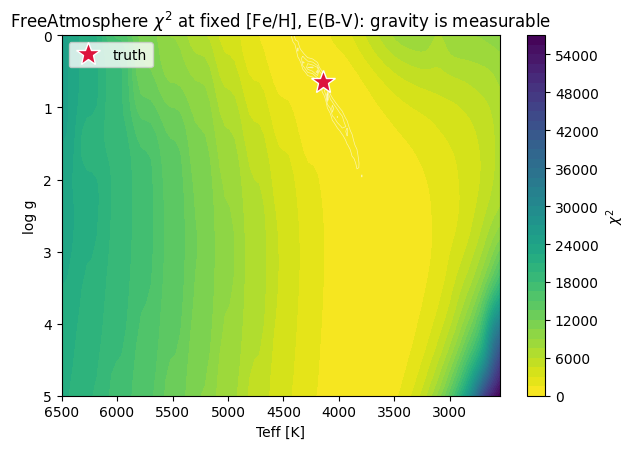

conditional log g range within Δχ²<4: [0.44, 0.89]  (dwarf gravities ~4.5 are excluded when [Fe/H] and E(B-V) are known)


In [4]:
teff_axis = np.linspace(float(phot.axes[0][0]) + 50, 6500.0, 90)
logg_axis = np.linspace(0.0, 5.0, 80)


@jax.jit
def chi2_free(teff, logg):
    pred = free.predict_mags(model, {"teff": teff, "logg": logg, "feh": TRUTH["feh"],
                                     "mu": 0.0, "ebmv": TRUTH["ebmv"]})[fidx]
    dmu = jnp.mean(mags_obs - pred)  # optimal grey offset (distance/radius/zeropoint)
    return jnp.sum(((pred + dmu - mags_obs) / SIG) ** 2)


tt, gg = jnp.meshgrid(jnp.asarray(teff_axis), jnp.asarray(logg_axis), indexing="ij")
chi2_map_free = np.asarray(jax.vmap(jax.vmap(chi2_free))(tt, gg))

fig, ax = plt.subplots(figsize=(6.4, 4.6))
lev = np.array([1, 2, 4, 8, 16, 32]) + float(chi2_map_free.min())
cs = ax.contourf(teff_axis, logg_axis, chi2_map_free.T, levels=40, cmap="viridis_r")
ax.contour(teff_axis, logg_axis, chi2_map_free.T, levels=lev, colors="w",
           linewidths=0.5, alpha=0.6)
ax.plot(TRUTH_TEFF, TRUTH_LOGG, "*", ms=18, mfc="crimson", mec="w", label="truth")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel("Teff [K]")
ax.set_ylabel("log g")
ax.set_title("FreeAtmosphere $\\chi^2$ at fixed [Fe/H], E(B-V): gravity is measurable")
fig.colorbar(cs, ax=ax, label="$\\chi^2$")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

col = chi2_map_free.min(axis=0)  # profile Teff -> chi2(logg)
within = logg_axis[col < col.min() + 4.0]
print(f"conditional log g range within Δχ²<4: [{within.min():.2f}, {within.max():.2f}]  "
      f"(dwarf gravities ~4.5 are excluded when [Fe/H] and E(B-V) are known)")

## 3. The isochrone removes the dwarf

Now `MISTTrack`, with E(B-V) still free. The isochrone confines (Teff, log g)
to the evolutionary track, so a star that matches the observed colours can
only be the giant — the dwarf gets **zero** posterior mass, and log g
collapses from the free-atmosphere width onto the giant branch. That is the
discrete win, and it comes with mass, age and radius as a dividend.

In [5]:
key, sk = jax.random.split(key)
t0 = time.time()
res_free = fit_nss(make_loglike(track), track.default_priors(), key=sk, data=mags_obs,
                   n_live=1200, n_posterior_samples=3000)
print(f"MISTTrack, E(B-V) free: {time.time() - t0:.0f} s, logZ = {float(res_free.logz):.2f}")
mist_free = atmos_frame(track, res_free)
print(f"  P(dwarf | log g > 3.5) = {float((mist_free['logg'] > 3.5).mean()):.1%}   "
      f"<- the isochrone rules the dwarf out")
report(mist_free, ["logg", "teff", "feh", "ebmv", "dist_pc"])

MISTTrack, E(B-V) free: 191 s, logZ = 19.73


  P(dwarf | log g > 3.5) = 0.0%   <- the isochrone rules the dwarf out
  logg          0.818  [    0.703,     0.984]   truth 0.6447012900681379
  teff       4201.251  [ 4172.280,  4245.385]   truth 4142.77450609628
  feh          -1.382  [   -1.547,    -1.162]   truth -1.5
  ebmv          0.101  [    0.068,     0.135]   truth 0.02
  dist_pc    8421.720  [ 7351.287,  9339.953]   truth 10000.0


But look at the point estimates above: log g, E(B-V), [Fe/H] and distance are
all biased. The dwarf is gone, yet the answer is *confidently wrong*. The
next section shows why.

## 4. The reddening–metallicity valley

Scan the `MISTTrack` chi2 over (E(B-V), [Fe/H]), profiling out the
evolutionary phase `x_eep` (both the giant and the main sequence of every
track are tried) and the distance, with mass held at the truth. The minimum
is not a point — it is a **diagonal ridge**: extra reddening can be paid for
by raising the metallicity, all the way from the metal-poor truth toward
solar. This is a property of the model and the bandpasses, independent of any
sampler, and it is what drags the §3 posterior off the truth.

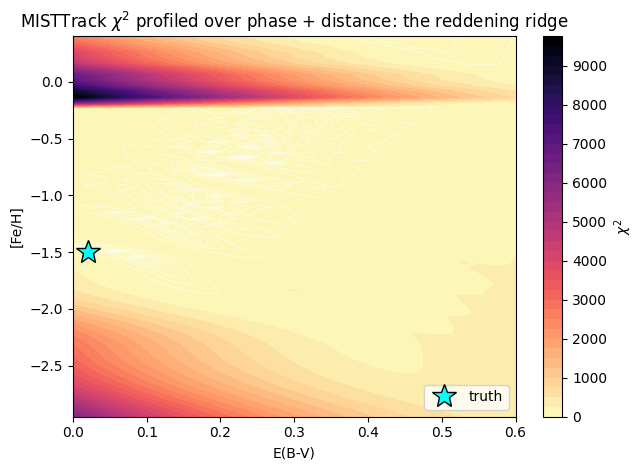

[Fe/H] within Δχ²<4 of the best fit: [-1.59, -0.28]  (truth -1.50) — the ridge runs metal-poor -> near-solar


In [6]:
feh_axis = np.linspace(float(iso.axes[2][0]) + 0.05, 0.4, 70)
ebmv_axis = np.linspace(0.0, 0.6, 70)
xeep_scan = jnp.linspace(0.02, 0.98, 48)


@jax.jit
def chi2_track(ebmv, feh):
    def at_xeep(xe):
        pred = track.predict_mags(
            model, {"mini": TRUTH["mini"], "x_eep": xe, "feh": feh,
                    "dist_pc": 10000.0, "ebmv": ebmv})[fidx]
        dmu = jnp.mean(mags_obs - pred)  # optimal distance (grey offset)
        return jnp.sum(((pred + dmu - mags_obs) / SIG) ** 2)

    return jnp.min(jax.vmap(at_xeep)(xeep_scan))


ee, ff = jnp.meshgrid(jnp.asarray(ebmv_axis), jnp.asarray(feh_axis), indexing="ij")
chi2_map_track = np.asarray(jax.vmap(jax.vmap(chi2_track))(ee, ff))

fig, ax = plt.subplots(figsize=(6.6, 4.8))
lev = np.array([1, 2.3, 4, 6.2, 9.2, 16, 32]) + float(chi2_map_track.min())
cs = ax.contourf(ebmv_axis, feh_axis, chi2_map_track.T, levels=40, cmap="magma_r")
ax.contour(ebmv_axis, feh_axis, chi2_map_track.T, levels=lev, colors="w",
           linewidths=0.5, alpha=0.6)
ax.plot(TRUTH["ebmv"], TRUTH["feh"], "*", ms=18, mfc="cyan", mec="k", label="truth")
ax.set_xlabel("E(B-V)")
ax.set_ylabel("[Fe/H]")
ax.set_title("MISTTrack $\\chi^2$ profiled over phase + distance: the reddening ridge")
fig.colorbar(cs, ax=ax, label="$\\chi^2$")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

ridge = feh_axis[chi2_map_track.min(axis=0) < chi2_map_track.min() + 4.0]
print(f"[Fe/H] within Δχ²<4 of the best fit: [{ridge.min():+.2f}, {ridge.max():+.2f}]  "
      f"(truth {TRUTH['feh']:+.2f}) — the ridge runs metal-poor -> near-solar")

## 5. Fixing E(B-V) collapses the ridge

Pin E(B-V) at the truth — the information a dust map or a redder band would
supply — and refit. The ridge is a line in the (E(B-V), [Fe/H]) plane; fixing
one coordinate cuts across it, and the posterior contracts onto the truth in
every parameter, to better than 1%.

In [7]:
track_fixed = MISTTrack(iso, ebmv_range=(0.019, 0.021))
key, sk = jax.random.split(key)
t0 = time.time()
res_fix = fit_nss(make_loglike(track_fixed), track_fixed.default_priors(), key=sk, data=mags_obs,
                  n_live=600, n_posterior_samples=2000)
print(f"MISTTrack, E(B-V) fixed: {time.time() - t0:.0f} s, logZ = {float(res_fix.logz):.2f}")
mist_fix = atmos_frame(track_fixed, res_fix)
report(mist_fix, ["logg", "teff", "feh", "dist_pc"])

MISTTrack, E(B-V) fixed: 123 s, logZ = 16.96


  logg          0.655  [    0.608,     0.721]   truth 0.6447012900681379
  teff       4147.375  [ 4141.927,  4152.778]   truth 4142.77450609628
  feh          -1.501  [   -1.593,    -1.382]   truth -1.5
  dist_pc    9934.836  [ 9202.435, 10269.216]   truth 10000.0


## 6. A parallax tightens distance — but does *not* break this ridge

Fixing E(B-V) is a reddening constraint. A **parallax** is a *distance*
constraint, and it is the lever `tengri_stars.branch` leans on. It drops into
the current parametrization with **no change**: keep E(B-V) free, keep the
`distance_prior`, and add a Gaussian parallax term to the likelihood — the
continuous analogue of the P(ϖ | branch) factor Ani's discrete mixture
carries. (`distance_prior='none'` is the documented hook if you would rather
let the parallax be the *only* distance information.)

In [8]:
VARPI_TRUE = 1000.0 / TRUTH["dist_pc"]  # parallax [mas]: d = 10 kpc -> 0.1 mas
SIGMA_VARPI = 0.015  # mas — an excellent measurement at 10 kpc (best case, to be fair to it)
key, pk = jax.random.split(key)
varpi_obs = float(VARPI_TRUE + SIGMA_VARPI * jax.random.normal(pk, ()))
print(f"parallax: true {VARPI_TRUE:.3f} mas, observed {varpi_obs:.3f} +/- {SIGMA_VARPI} mas")


def loglike_parallax(p, data):
    pred = track.predict_mags(model, p)[fidx]
    lp = -0.5 * jnp.sum(((pred - data) / SIG) ** 2) + track.log_prior_extra(p)
    varpi_pred = 1000.0 / p["dist_pc"]  # mas
    return lp - 0.5 * ((varpi_pred - varpi_obs) / SIGMA_VARPI) ** 2


key, sk = jax.random.split(key)
t0 = time.time()
res_plx = fit_nss(loglike_parallax, track.default_priors(), key=sk, data=mags_obs,
                  n_live=1200, n_posterior_samples=3000)
print(f"MISTTrack, E(B-V) free + parallax: {time.time() - t0:.0f} s, "
      f"logZ = {float(res_plx.logz):.2f}")
mist_plx = atmos_frame(track, res_plx)
report(mist_plx, ["logg", "teff", "feh", "ebmv", "dist_pc"])

parallax: true 0.100 mas, observed 0.126 +/- 0.015 mas


MISTTrack, E(B-V) free + parallax: 245 s, logZ = 17.56
  logg          1.049  [    0.967,     1.100]   truth 0.6447012900681379
  teff       4278.487  [ 4255.653,  4301.782]   truth 4142.77450609628
  feh          -1.128  [   -1.234,    -1.064]   truth -1.5
  ebmv          0.141  [    0.127,     0.161]   truth 0.02
  dist_pc    7726.717  [ 7233.896,  8116.710]   truth 10000.0


Read the distance line against §3: the parallax has pulled the distance
posterior in tight — that part works exactly as advertised. But log g, [Fe/H]
and E(B-V) are **still biased**: the parallax has not moved them toward the
truth. It pinned the distance, and through the isochrone that *selects a point
along the ridge* — but selecting a point is not collapsing the ridge. The
point it selects is still a reddened, metal-rich, higher-gravity impostor;
here, with an observed parallax that happened to scatter high, it is one that
has slid a little *further* from the truth than the E(B-V)-free fit.

The reason is worth internalising. The reddening ridge is a degeneracy of
colour *shape* — reddening reddens, metallicity moves CaHK, and the two trade
off. Distance is *grey*: it slides every band together and never changes a
colour, so the parallax picks *where along the ridge* you sit but cannot
arbitrate the colour-shape trade *across* it. What a parallax genuinely
resolves is a difference in luminosity, and along the metal-poor giant branch
the luminosity contrast between the competing solutions is small — a fraction
of a magnitude, not the ~7 mag between a dwarf and a giant.

That is the crucial distinction from Ani's branch test. There the two
hypotheses are a **dwarf and a giant**, whose luminosities differ enormously,
so a parallax is decisive — it does the same job the isochrone already does
for `MISTTrack` (§3), by a different route. Neither the isochrone nor a
parallax touches the *intra-giant* reddening ridge; only a constraint on the
reddening itself (a dust map, §5) or a longer colour baseline (redder bands)
does.

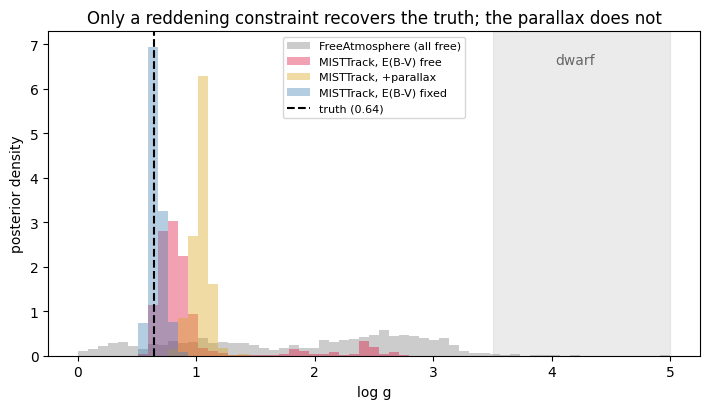

In [9]:
# log g under four treatments: only the reddening constraint (fixed E(B-V))
# lands on the truth; the parallax tracks the E(B-V)-free fit.
fig, ax = plt.subplots(figsize=(7.2, 4.2))
bins = np.linspace(0.0, 5.0, 60)
for frame, lab, c in ((freeatm, "FreeAtmosphere (all free)", "0.5"),
                      (mist_free, "MISTTrack, E(B-V) free", "crimson"),
                      (mist_plx, "MISTTrack, +parallax", "goldenrod"),
                      (mist_fix, "MISTTrack, E(B-V) fixed", "steelblue")):
    ax.hist(frame["logg"], bins=bins, density=True, histtype="stepfilled",
            alpha=0.4, color=c, label=lab)
ax.axvline(TRUTH_LOGG, color="k", ls="--", lw=1.5, label=f"truth ({TRUTH_LOGG:.2f})")
ax.axvspan(3.5, 5.0, color="0.85", alpha=0.5, zorder=0)
ax.text(4.2, ax.get_ylim()[1] * 0.9, "dwarf", ha="center", color="0.4")
ax.set_xlabel("log g")
ax.set_ylabel("posterior density")
ax.set_title("Only a reddening constraint recovers the truth; the parallax does not")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The corner confirms it parameter by parameter: the parallax (gold) pulls the
distance axis in tight, but log g, Teff and [Fe/H] slide along the ridge
rather than onto the crosshairs; only fixing E(B-V) (blue) lands on the truth.

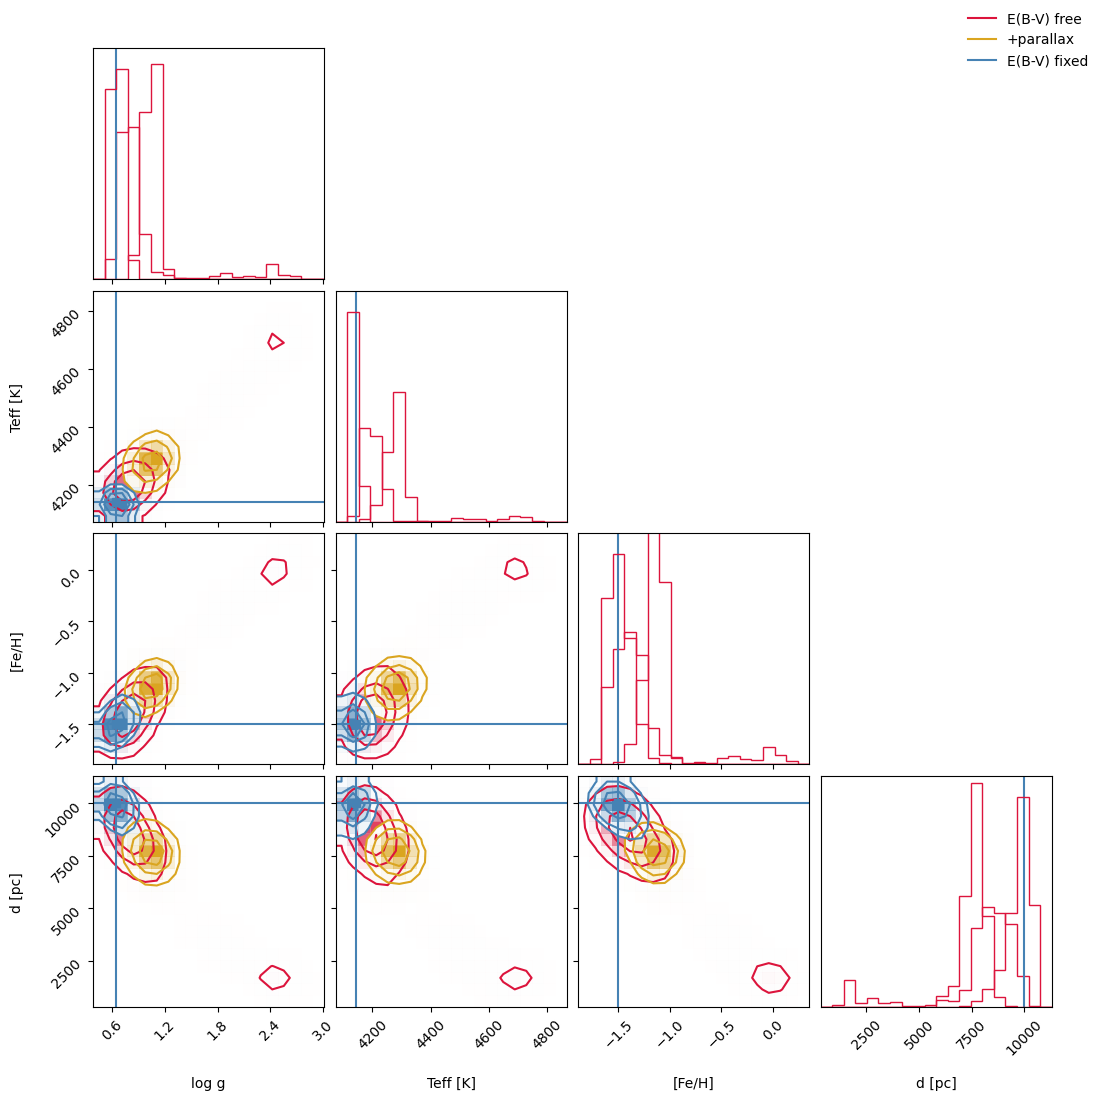

In [10]:
overlay_corner(
    [mist_free, mist_plx, mist_fix],
    names=["logg", "teff", "feh", "dist_pc"],
    labels=["log g", "Teff [K]", "[Fe/H]", "d [pc]"],
    legend_labels=["E(B-V) free", "+parallax", "E(B-V) fixed"],
    colors=["crimson", "goldenrod", "steelblue"],
    truths={"logg": TRUTH_LOGG, "teff": TRUTH_TEFF, "feh": TRUTH["feh"],
            "dist_pc": TRUTH["dist_pc"]},
)
plt.show()

## 7. What this means, and what breaks the degeneracy

The isochrone prior does exactly what it promises — and no more. It removes
the discrete dwarf/giant ambiguity that a radius-free grid leaves wide open
(§2 → §3: a broad gravity posterior collapses onto the giant with zero dwarf
mass), which is real, hard-won information a free-atmosphere fit does not
have, and it hands back mass, age and radius. But it does **not** manufacture
a reddening measurement out of five optical bands. When E(B-V) is free, the
reddening–metallicity ridge (§4) means the posterior is broad and biased —
and, the trap, a low-resolution sampler can report that ridge as a
*confident* wrong answer.

What breaks it is a constraint on the **reddening** — a colour-shape lever:

- **A dust-map prior on E(B-V)** — the cheapest fix. For a halo star at known
  sky position, a 3-D extinction map pins E(B-V) to a tight Gaussian; pass it
  as the `ebmv` prior. Fixing E(B-V) outright (§5) recovers the star to <1%.
- **Redder photometry.** Reddening and temperature separate as more of the
  SED is sampled; near-infrared bands break the tilt that u, g, r, i and CaHK
  cannot. Notebook 07 quantifies the per-band information content.

A **parallax or known distance modulus** is a *distance* lever, not a
reddening one, and §6 shows the distinction concretely: it tightens the
distance sharply but leaves the reddening ridge — and the log g, Teff and
[Fe/H] bias — essentially intact, because distance is grey and the ridge is a
colour-shape trade. Its real power is on the **dwarf/giant** contrast, whose
~7-mag luminosity gap a parallax resolves at once. That is the axis
`tengri_stars.branch` operates on: it pins each hypothesis to the observed g
so the absolute magnitude cancels from the colour χ², then lets the parallax
arbitrate the two branches (notebooks 08-10). For `MISTTrack` the isochrone
already closes that axis (§3), so a parallax there is confirmation, not new
leverage on the ridge.

`MISTTrack` (continuous, gradient-friendly, one track) and
`tengri_stars.branch` (discrete, two hypotheses, parallax-weighted) are
complementary tools for the same problem: use the track when you have a dust
prior or redder data and want full posteriors with derived mass and age; use
the branch test when a parallax or distance modulus is the constraint you
have and the dwarf/giant call is the question.